### Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Installing Dependencies

In [2]:
!pip install -q timm

In [10]:
!pip install -q seaborn
import seaborn as sns

### Imports and Config

In [3]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn. preprocessing import LabelEncoder
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

# Configuration
BASE_DIR = "/content/drive/MyDrive/car_model"
IMG_DIR = os.path.join(BASE_DIR, "processed")
CSV_PATH = os.path.join(BASE_DIR, "shuffled_labels.csv")
SAVE_DIR = os.path.join(BASE_DIR, "checkpoints")
ENCODER_DIR = os.path.join(BASE_DIR, "encoders")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(ENCODER_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-4
IMG_SIZE = 224
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


### Loading and Encoding Labels

In [4]:
df = pd.read_csv(CSV_PATH)

#Add .jpg extension if missing
df["filename"] = df["filename"].apply(
    lambda x: x if x.endswith(".jpg") else x + ".jpg"
)

#Encode each ResNet50 head's labels
le_make = LabelEncoder()
le_model = LabelEncoder()
le_year_range = LabelEncoder()

df["make_enc"] = le_make.fit_transform(df["make"])
df["model_enc"] = le_model.fit_transform(df["model"])
df["year_range_enc"] = le_year_range.fit_transform(df["year_range"])

#Save encoders so we can decode predictions later in VS Code
def save_encoder(le, name):
  mapping = {str(i): cls for i, cls in enumerate(le.classes_)}
  with open(os.path.join(ENCODER_DIR, f"{name}.json"), "w") as f:
    json.dump(mapping, f, indent=2)

save_encoder(le_make, "make")
save_encoder(le_model, "model")
save_encoder(le_year_range, "year_range")

print("Make Classes:", le_make.classes_)
print("Model Classes:", le_model.classes_)
print("Year Range Classes:", le_year_range.classes_)

NUM_MAKES = len(le_make.classes_)
NUM_MODELS = len(le_model.classes_)
NUM_YEARS = len(le_year_range.classes_)

Make Classes: ['changan' 'ford' 'volkswagen']
Model Classes: ['estar' 'fusion' 'id4']
Year Range Classes: ['2010_2012' '2013_2016' '2017' '2018_2020' '2020_2026']


### Dataset Class

In [5]:
class CarDataset(Dataset):
  def __init__(self, df, img_dir, transform=None):
    self.df = df.reset_index(drop=True)
    self.img_dir = img_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    img_path = os.path.join(self.img_dir, row["filename"])

    try:
      img = Image.open(img_path).convert("RGB")
    except Exception:
      # Return blank image if file is missing
      img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0,0,0))

    if self.transform:
      img = self.transform(img)

    return(
        img,
        torch.tensor(row["make_enc"], dtype=torch.long),
        torch.tensor(row["model_enc"], dtype=torch.long),
        torch.tensor(row["year_range_enc"], dtype=torch.long)
    )

### Transforms and Dataloaders

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["make_enc"])

train_dataset = CarDataset(train_df, IMG_DIR, train_transform)
val_dataset = CarDataset(val_df, IMG_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 6708 | Val: 1677


### Multi-Head ResNet50 Model

In [7]:
class MultiHeadResNet50(nn.Module):
  def __init__(self, num_makes, num_models, num_year_ranges):
    super().__init__()

    # Load the pretrained ResNet50 backbone
    backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Remove the final classification layer
    self.backbone = nn.Sequential(*list(backbone.children())[:-1])

    in_features = 2048 # ResNet50 output size

    # Shared fully connected layer
    self.shared_fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
    )

    # Three separate heads
    self.head_make = nn.Linear(512, num_makes)
    self.head_model = nn.Linear(512, num_models)
    self.head_year_range = nn.Linear(512, num_year_ranges)

  def forward(self, x):
    x = self.backbone(x)
    x = self.shared_fc(x)
    return(
        self.head_make(x),
        self.head_model(x),
        self.head_year_range(x),
    )

model = MultiHeadResNet50(NUM_MAKES, NUM_MODELS, NUM_YEARS).to(DEVICE)
print(model)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 68.3MB/s]


MultiHeadResNet50(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

### Training Loop

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

history = {"train_loss": [], "val_loss": [], "val_acc_make": [], "val_acc_model": [], "val_acc_year": []}

best_val_loss = float("inf")

for epoch in range(EPOCHS):
  # Training
  model.train()
  train_loss = 0

  for imgs, labels_make, labels_model, labels_year in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
    imgs = imgs.to(DEVICE)
    labels_make = labels_make.to(DEVICE)
    labels_model = labels_model.to(DEVICE)
    labels_year = labels_year.to(DEVICE)

    optimizer.zero_grad()
    out_make, out_model, out_year = model(imgs)

    loss = (
        criterion(out_make, labels_make) +
        criterion(out_model, labels_model) +
        criterion(out_year, labels_year)
    )

    loss.backward()
    optimizer.step()
    train_loss += loss.item()

  train_loss /= len(train_loader)

  # Validation
  model.eval()
  val_loss = 0
  correct_make = correct_model = correct_year = total = 0

  with torch.no_grad():
    for imgs, labels_make, labels_model, labels_year in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
      imgs = imgs.to(DEVICE)
      labels_make = labels_make.to(DEVICE)
      labels_model = labels_model.to(DEVICE)
      labels_year = labels_year.to(DEVICE)

      out_make, out_model, out_year = model(imgs)

      loss = (
          criterion(out_make, labels_make) +
          criterion(out_model, labels_model) +
          criterion(out_year, labels_year)
      )
      val_loss += loss.item()

      correct_make += (out_make.argmax(1) == labels_make).sum().item()
      correct_model += (out_model.argmax(1) == labels_model).sum().item()
      correct_year += (out_year.argmax(1) == labels_year).sum().item()
      total += labels_make.size(0)

  val_loss /= len(val_loader)
  acc_make = correct_make / total * 100
  acc_model = correct_model / total * 100
  acc_year = correct_year / total * 100

  scheduler.step()

  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)
  history["val_acc_make"].append(acc_make)
  history["val_acc_model"].append(acc_model)
  history["val_acc_year"].append(acc_year)

  print(f"\nEpoch {epoch+1}/{EPOCHS}")
  print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
  print(f"  Val Acc — Make: {acc_make:.2f}% | Model: {acc_model:.2f}% | Year: {acc_year:.2f}%")

  # Save best model
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
    print("Best Model Saved")


Epoch 1/30 [Train]:   6%|▌         | 12/210 [01:51<21:45,  6.59s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/30 [Train]:  30%|███       | 64/210 [07:57<15:20,  6.30s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/30 [Val]:  34%|███▍      | 18/53 [02:04<03:24,  5.83s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/30 [Val]: 100%|██████████| 53/53 [06:05<00:00,  6.90s/it]



Epoch 1/30
  Train Loss: 1.0796 | Val Loss: 0.5194
  Val Acc — Make: 97.97% | Model: 98.09% | Year: 83.54%
Best Model Saved


Epoch 2/30 [Train]:  20%|██        | 43/210 [00:33<01:51,  1.50it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/30 [Train]:  25%|██▍       | 52/210 [00:39<02:02,  1.29it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/30 [Val]:  34%|███▍      | 18/53 [00:11<00:18,  1.93it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/30 [Val]: 100%|██████████| 53/53 [00:29<00:00,  1.79it/s]



Epoch 2/30
  Train Loss: 0.3337 | Val Loss: 0.2653
  Val Acc — Make: 99.34% | Model: 99.40% | Year: 91.83%
Best Model Saved


Epoch 3/30 [Train]:   8%|▊         | 16/210 [00:15<03:34,  1.10s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 3/30 [Train]:  26%|██▌       | 55/210 [00:43<01:33,  1.66it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 3/30 [Val]:  34%|███▍      | 18/53 [00:10<00:21,  1.65it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 3/30 [Val]: 100%|██████████| 53/53 [00:29<00:00,  1.81it/s]


...


Epoch 28/30
  Train Loss: 0.0071 | Val Loss: 0.0707
  Val Acc — Make: 100.00% | Model: 100.00% | Year: 98.69%


Epoch 29/30 [Train]:   3%|▎         | 7/210 [00:07<03:09,  1.07it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 29/30 [Train]:  17%|█▋        | 36/210 [00:27<01:51,  1.57it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 29/30 [Val]:  34%|███▍      | 18/53 [00:11<00:16,  2.17it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 29/30 [Val]: 100%|██████████| 53/53 [00:29<00:00,  1.79it/s]



Epoch 29/30
  Train Loss: 0.0109 | Val Loss: 0.0569
  Val Acc — Make: 100.00% | Model: 100.00% | Year: 98.57%


Epoch 30/30 [Train]:   4%|▍         | 9/210 [00:07<03:19,  1.01it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 30/30 [Train]:  25%|██▍       | 52/210 [00:38<01:55,  1.37it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 30/30 [Val]:  34%|███▍      | 18/53 [00:10<00:15,  2.21it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 30/30 [Val]: 100%|██████████| 53/53 [00:29<00:00,  1.80it/s]


Epoch 30/30
  Train Loss: 0.0100 | Val Loss: 0.0640
  Val Acc — Make: 100.00% | Model: 100.00% | Year: 98.63%


### Plotting Training Curves

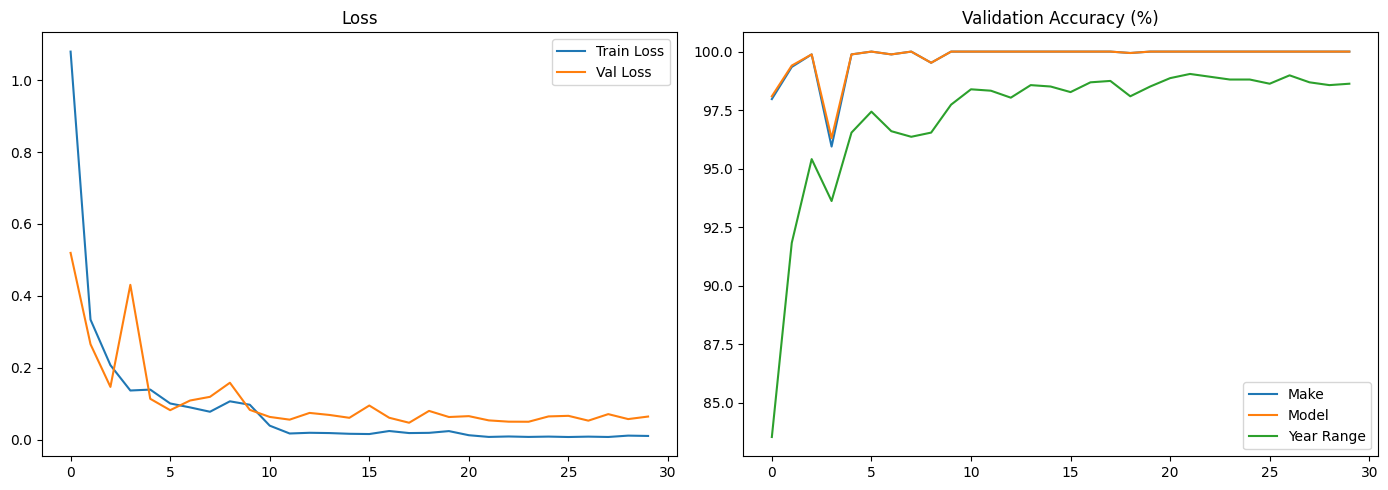

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_acc_make"], label="Make")
axes[1].plot(history["val_acc_model"], label="Model")
axes[1].plot(history["val_acc_year"], label="Year Range")
axes[1].set_title("Validation Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "training_curves.png"))
plt.show()

### Testing Possible Data Leakage

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


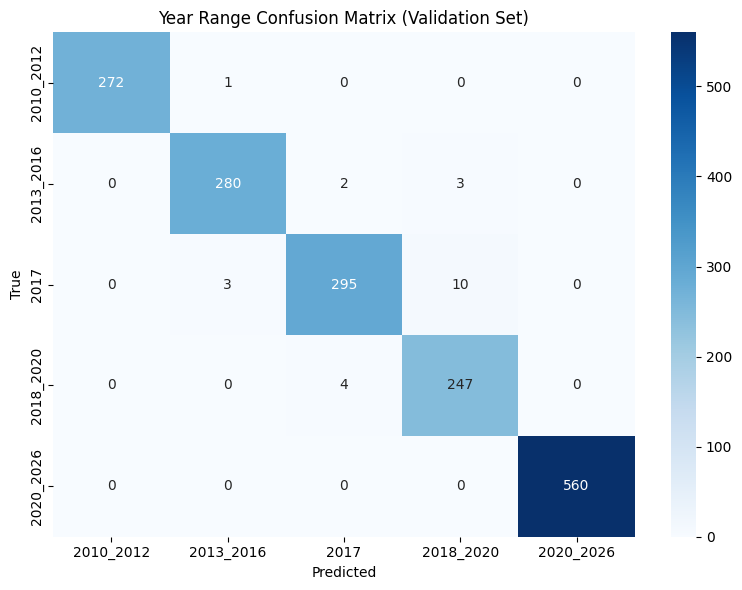

In [11]:
# Check if model is actually learning visual features
# or just cheating via correlations

from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_make_preds  = []
all_model_preds = []
all_year_preds  = []
all_make_true   = []
all_year_true   = []

with torch.no_grad():
    for imgs, labels_make, labels_model, labels_year in val_loader:
        imgs = imgs.to(DEVICE)
        out_make, out_model, out_year = model(imgs)

        all_make_preds.extend(out_make.argmax(1).cpu().numpy())
        all_year_preds.extend(out_year.argmax(1).cpu().numpy())
        all_make_true.extend(labels_make.numpy())
        all_year_true.extend(labels_year.numpy())

# Plot confusion matrix for year range (the hardest head)
cm = confusion_matrix(all_year_true, all_year_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le_year_range.classes_,
    yticklabels=le_year_range.classes_,
    cmap="Blues"
)
plt.title("Year Range Confusion Matrix (Validation Set)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "confusion_matrix.png"))
plt.show()

### Downloading from Colab to PC

In [12]:
from google.colab import files

files.download(os.path.join(SAVE_DIR, "best_model.pth"))
files.download(os.path.join(ENCODER_DIR, "make.json"))
files.download(os.path.join(ENCODER_DIR, "model.json"))
files.download(os.path.join(ENCODER_DIR, "year_range.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>